In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from pathlib import Path
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W

from utils.colors import C3, M, MS
from utils.utils import progress_bar
from utils.solvers import fast_svd_solver
from utils.problem_setup import TestProblemsSetup
from utils.metrics import error_auc_iou, error_movers
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
setup = TestProblemsSetup(n=64)
problems = setup.get_test_problems()
problem_params = setup.problem_params

In [3]:
def experiment_rsvd_over_k(
        pid: str,
        problems: dict,
        k_range: np.ndarray,
        p_list: list,
        repeat: int = 1,
        lambda_: float = 1e-4,
    ):
    """
    Experiment: measure rSVD error for different k and p. (pid = I, II, or III.)
    """
    pb = problems[pid]
    nk = len(k_range)

    records = []
    step = 0
    for p in p_list:
        for k in k_range:
            for r in range(repeat):
                step += 1

                # Solve inverse problem using matrix-free rSVD
                rsvd: MatrixFreeRSVD = pb['rsvd']
                rsvd.mf_rsvd(k=k, p=p, seed=SEED + r + p)
                w = get_approximate_W(Vk=rsvd.VkT.T, M_dx=rsvd.M_dx)
                x_hat = fast_svd_solver(
                    y=pb['y'],
                    U=rsvd.Uk,
                    s=rsvd.Sk,
                    V=rsvd.VkT.T,
                    M_partial=rsvd.M_ds,
                    M=rsvd.M_dx,
                    w=w,
                    lam=lambda_
                )

                # Measure the error
                record = {
                    'p': p,
                    'k': k,
                    'repeat': r,
                    'euclidean': np.linalg.norm(pb['x'] - x_hat),
                    'emd': error_movers(pb['x'], x_hat),
                    'auc_iou': error_auc_iou(pb['x'], x_hat)[0],
                }

                records.append(record)
                progress_bar(step, len(p_list) * nk * repeat, end_text=f" [{p=},{k=}]")

    return pd.DataFrame(records)


def experiment_full_rank(pid: str, problems: dict):
    """
    Experiment: measure the weighted Tikhonov solution error.
    """
    pb = problems[pid]

    exact = ExactForwardOperator(pb['V_h'])
    f_hat = solve_explicit(
        operator=exact,
        w=exact.get_weights(),
        y=pb['y'],
        lambda_=1e-4
    )
    x_hat = f_hat.vector().get_local()

    record_exact = {
        'euclidean': np.linalg.norm(pb['x'] - x_hat),
        'emd': error_movers(pb['x'], x_hat),
        'auc_iou': error_auc_iou(pb['x'], x_hat)[0],
    }
    return pd.DataFrame([record_exact])


def save_results(results, repeat):
    result_dir = Path("../../results")

    for name, df in results.items():
        file_path = result_dir / f"{name}_r{repeat}.csv"
        print(f"Saving {file_path}")
        df.to_csv(file_path)


In [4]:
k_range = np.arange(5, 250, 10)
p_list = [0, 5, 10]
repeat = 30

results = {}
for pid in ('I', 'II', 'III'):
    results[pid] = experiment_rsvd_over_k(
        pid=pid,
        problems=problems,
        k_range=k_range,
        p_list=p_list,
        repeat=repeat
    )
    results[pid + 'fr'] = experiment_full_rank(
        pid=pid,
        problems=problems
    )

# Save results to disk
save_results(results, repeat)

[##############################] 2250/2250 [p=10,k=245]
[##############################] 2250/2250 [p=10,k=245]
[##############################] 2250/2250 [p=10,k=245]
Saving ../../results/I_r30.csv
Saving ../../results/Ifr_r30.csv
Saving ../../results/II_r30.csv
Saving ../../results/IIfr_r30.csv
Saving ../../results/III_r30.csv
Saving ../../results/IIIfr_r30.csv


In [5]:
# Load results from disk
results = {}
result_dir = Path("../../results")
for pid in ('I', 'II', 'III'):
    file_path_df = result_dir / f"{pid}_r{repeat}.csv"
    file_path_df_fr = result_dir / f"{pid}fr_r{repeat}.csv"
    results[pid] = pd.read_csv(file_path_df)
    results[pid + 'fr'] = pd.read_csv(file_path_df_fr)


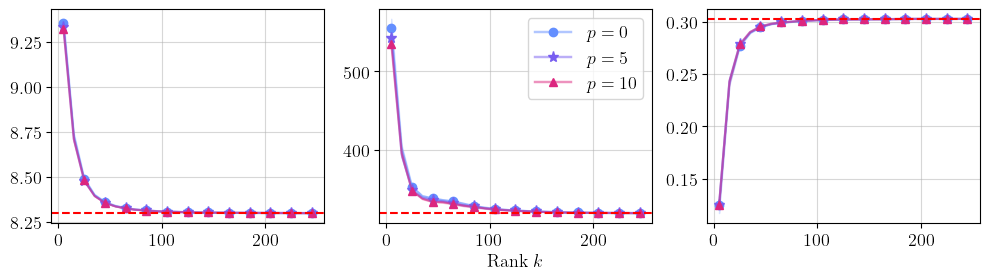

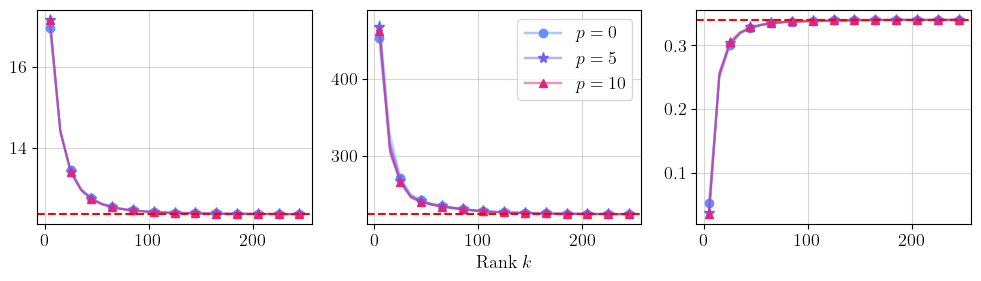

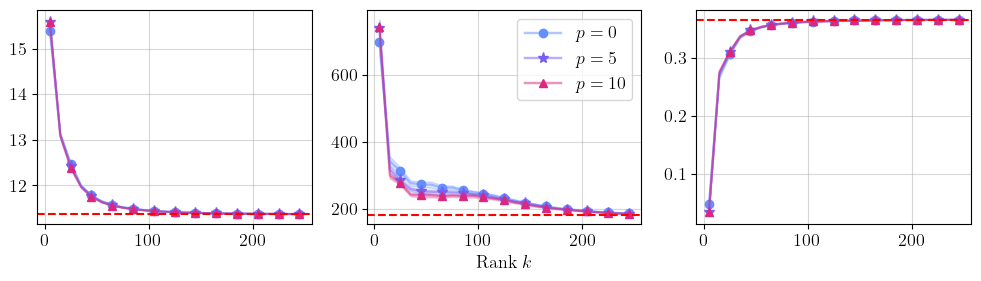

In [6]:
def save_plot(fig_name: str) -> None:
    if fig_name is not None:
        path = Path(f"../../figures/{fig_name}.png")
        if not path.exists():
            plt.savefig(path, dpi=300, bbox_inches="tight")
        else:
            print(path, 'already exists')
    

def plot_rsvd_over_k(df, df_fr, marker_sep = 1, fig_name=None, title=True):
    p_list = df.p.unique()
    stats = df.groupby(["p", "k"]).agg(["mean", "std", "count"])

    fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True)
    axes = axes.flatten()

    dists = ['euclidean', 'emd', 'auc_iou']
    titles = {'euclidean': 'Euclidean', 'emd': 'EMD', 'auc_iou': 'AUC-IoU'}

    for ax, dist in zip(axes, dists):
        key = dist.lower()

        handles, labels = [], []
        for i, p in enumerate(p_list):
            stats_p = stats.loc[p]

            # 95% CI
            mean = stats_p[(key, "mean")]
            std = stats_p[(key, "std")]
            n = stats_p[(key, "count")]
            ci95 = 1.96 * std / np.sqrt(n)

            k_vals = mean.index
            ax.plot(k_vals, mean, label=f'{p=}', c=C3[i], alpha=0.5)
            ax.plot(k_vals[::marker_sep], mean[::marker_sep], M[i], ms=MS[i], c=C3[i])
            ax.fill_between(k_vals, mean - ci95, mean + ci95, alpha=0.25, color=C3[i])

            legend_line = Line2D([0], [0], color=C3[i], linewidth=1.75, alpha=0.5)
            legend_marker = Line2D([0], [0], color=C3[i], marker=M[i], markersize=MS[i], linestyle='None')
            handles.append((legend_line, legend_marker))
            labels.append(f'$p={p}$')

        ax.axhline(df_fr[key][0], c='r', ls='--')

        ax.grid(alpha=.5)
        if title: ax.set_title(titles[dist])

    axes[1].set_xlabel("Rank $k$")
    axes[1].legend(handles=handles, labels=labels)
    
    #axes[1].legend(loc='upper right', ncols=3, bbox_to_anchor=(1.25, -0.3), fontsize=13)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.2)
    save_plot(fig_name)
    plt.show()


for pid in ('I', 'II', 'III'):
    plot_rsvd_over_k(results[pid], results[pid + 'fr'], title=False, marker_sep=2)